# BiLSTM

Modelo de deep learning para clasificacion binaria de plagio en pares de codigo.

Se usa una arquitectura BiLSTM ya que es un enfoque de moderno de deep learning aplicados a deteccion de plagio, parafrasis y texto/codigo generado.


In [1]:
%pip -q install pyarrow fsspec huggingface_hub joblib seaborn scikit-learn tensorflow

In [2]:
from pathlib import Path
import io
import json
import keyword
import re
import tokenize

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
DATA_URL = "hf://datasets/nop12/python_plagiarism_code_dataset/data/train-00000-of-00001.parquet"

PROJECT_DIR = Path("/kaggle/working/code-plagiarism-benchmark") if Path("/kaggle").exists() else Path.cwd() / "code-plagiarism-benchmark"
FIGURES_DIR = PROJECT_DIR / "figures"
METRICS_DIR = PROJECT_DIR / "metrics"
MODELS_DIR = PROJECT_DIR / "models"
for folder in [FIGURES_DIR, METRICS_DIR, MODELS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project directory:", PROJECT_DIR)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.keras.utils.set_random_seed(RANDOM_STATE)


Project directory: /kaggle/working/code-plagiarism-benchmark


## 1. Carga y construcción de pares

Esta sección se encarga de cargar el conjunto de datos inicial y transformarlo en pares de código binarios, que son la base para el entrenamiento del modelo de detección de plagio.

-   **Pares positivos:** Se crean comparando el código original de un assignment (tarea) con sus versiones transformadas (plagiadas). Estos pares son etiquetados con un '1' indicando plagio.
-   **Pares negativos:** Se generan emparejando un código original de un assignment con un código de otro assignment seleccionado aleatoriamente. Estos pares son etiquetados con un '0' indicando ausencia de plagio.

Se utiliza una semilla fija para los procesos de aleatorización, asegurando así que la división de datos y la construcción de pares sean completamente reproducibles en cada ejecución. Además, se realizan divisiones de los datos en conjuntos de entrenamiento, validación y prueba.

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Raw dataset shape: (15176, 6)


,model,assignment,level,code,filename,level_num
0,deep-seek-coder,assignment1,level0,"def get_key_by_index(dictionary: dict, index: ...",deepseek_aw_a_f_t_a_d_k_s_e_b_i1733686123.6054...,0.0
1,deep-seek-coder,assignment1,level1,"def access_key(ditionary,key):\n return lis...",few_shot_deepseek-coder_aw_a_f_t_a_d_k_s_e_b_i...,1.0
2,deep-seek-coder,assignment1,level2,"def get_key_value(mapping, index):\n return...",few_shot_deepseek-coder_aw_a_f_t_a_d_k_s_e_b_i...,2.0
3,deep-seek-coder,assignment1,level3,"def access_key(ditionary, key):\n # Retriev...",few_shot_deepseek-coder_aw_a_f_t_a_d_k_s_e_b_i...,3.0
4,deep-seek-coder,assignment1,level4,"def access_key(ditionary, key):\n keys_list...",few_shot_deepseek-coder_aw_a_f_t_a_d_k_s_e_b_i...,4.0


,rows
level,
level0,1770
level1,1932
level2,1932
level3,1928
level4,1892
level5,1915
level6,1859
original,1948


Split sizes: 16094 3442 3380
Assignment split sizes: 681 146 147


,train,validation,test
no_plagio,8047,1721,1690
plagio,8047,1721,1690


,check,ok
0,train-val separados,True
1,train-test separados,True
2,val-test separados,True
3,train balanceado,True
4,validation balanceado,True
5,test balanceado,True


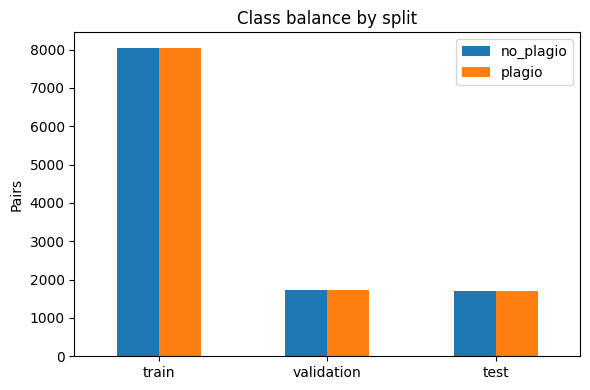

In [3]:
df = pd.read_parquet(DATA_URL)
df["level_num"] = df["level"].str.extract(r"level(\d+)").astype("float")

print("Raw dataset shape:", df.shape)
display(df.head())
display(df["level"].value_counts().sort_index().to_frame("rows"))


def build_pairs(data, random_state=RANDOM_STATE):
    originals = data[data["level"].eq("original")][["model", "assignment", "code"]].copy()
    originals = originals.rename(columns={"code": "code_a"})

    variants = data[data["level"].isin([f"level{i}" for i in range(1, 7)])].copy()
    variants = variants[["model", "assignment", "level", "level_num", "code"]]

    positives = variants.merge(originals, on=["model", "assignment"])
    positives = positives.rename(columns={"code": "code_b"})
    positives["label"] = 1

    rng = np.random.default_rng(random_state)
    original_pool = originals.drop_duplicates("assignment")[["assignment", "code_a"]]
    original_codes = dict(zip(original_pool["assignment"], original_pool["code_a"]))
    available_assignments = np.array(list(original_codes.keys()))

    negative_codes = []
    for assignment in positives["assignment"]:
        possible_assignments = available_assignments[available_assignments != assignment]
        random_assignment = rng.choice(possible_assignments)
        negative_codes.append(original_codes[random_assignment])

    negatives = positives.copy()
    negatives["code_b"] = negative_codes
    negatives["level"] = "negative"
    negatives["level_num"] = 0
    negatives["label"] = 0

    pairs = pd.concat([positives, negatives], ignore_index=True)
    return pairs[["assignment", "model", "level", "level_num", "code_a", "code_b", "label"]]


assignments = pd.Series(sorted(df["assignment"].unique()))
train_ids, temp_ids = train_test_split(assignments, test_size=0.30, random_state=RANDOM_STATE)
val_ids, test_ids = train_test_split(temp_ids, test_size=0.50, random_state=RANDOM_STATE)

train_df = build_pairs(df[df["assignment"].isin(train_ids)], random_state=RANDOM_STATE).reset_index(drop=True)
val_df = build_pairs(df[df["assignment"].isin(val_ids)], random_state=RANDOM_STATE + 1).reset_index(drop=True)
test_df = build_pairs(df[df["assignment"].isin(test_ids)], random_state=RANDOM_STATE + 2).reset_index(drop=True)

print("Split sizes:", len(train_df), len(val_df), len(test_df))
print("Assignment split sizes:", len(train_ids), len(val_ids), len(test_ids))

split_summary = pd.concat(
    [
        train_df["label"].value_counts().rename("train"),
        val_df["label"].value_counts().rename("validation"),
        test_df["label"].value_counts().rename("test"),
    ],
    axis=1,
).sort_index()
split_summary.index = ["no_plagio", "plagio"]
display(split_summary)

split_checks = pd.DataFrame({
    "check": ["train-val separados", "train-test separados", "val-test separados", "train balanceado", "validation balanceado", "test balanceado"],
    "ok": [
        set(train_ids).isdisjoint(set(val_ids)),
        set(train_ids).isdisjoint(set(test_ids)),
        set(val_ids).isdisjoint(set(test_ids)),
        train_df["label"].mean() == 0.5,
        val_df["label"].mean() == 0.5,
        test_df["label"].mean() == 0.5,
    ],
})
display(split_checks)

plt.figure(figsize=(6, 4))
split_summary.T.plot(kind="bar", ax=plt.gca())
plt.title("Class balance by split")
plt.ylabel("Pairs")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "class_balance.png", dpi=180)
plt.show()


## 2. Normalización del código

Antes de entrenar la red, el código fuente se somete a un proceso de normalización. Este paso es crucial para:

1.  **Reducir el ruido:** Se eliminan elementos irrelevantes como comentarios, saltos de línea, indentación y codificaciones que no aportan información semántica sobre la estructura del código.
2.  **Abstraer detalles específicos:** Los nombres de variables, funciones y literales (cadenas y números) se reemplazan por tokens genéricos (ID, STR, NUM, respectivamente). Esto evita que el modelo aprenda patrones basados en nombres concretos, que pueden variar ampliamente sin cambiar la funcionalidad del código.

Al aplicar esta normalización, el modelo se enfoca en aprender patrones de estructura y flujo de control, haciendo que la detección de plagio sea más robusta y generalizable a diferentes estilos de codificación y a ofuscaciones simples que solo cambian los nombres de los identificadores.

In [4]:
def normalize_code(src):
    try:
        tokens = []
        reader = io.StringIO(str(src)).readline

        for tok in tokenize.generate_tokens(reader):
            t, s = tok.type, tok.string

            if t in {
                tokenize.COMMENT,
                tokenize.NL,
                tokenize.NEWLINE,
                tokenize.INDENT,
                tokenize.DEDENT,
                tokenize.ENCODING,
            }:
                continue

            if t == tokenize.NAME and not keyword.iskeyword(s):
                tokens.append("ID")
            elif t == tokenize.STRING:
                tokens.append("STR")
            elif t == tokenize.NUMBER:
                tokens.append("NUM")
            else:
                tokens.append(s)

        return " ".join(tokens)

    except tokenize.TokenError:
        return re.sub(r"\s+", " ", str(src)).strip()


for split in [train_df, val_df, test_df]:
    split["norm_a"] = split["code_a"].map(normalize_code)
    split["norm_b"] = split["code_b"].map(normalize_code)

display(train_df[["level", "label", "norm_a", "norm_b"]].head())


,level,label,norm_a,norm_b
0,level1,1,"def ID ( ID , ID ) : return ID ( ID ) [ ID ]","def ID ( ID , ID ) : return ID ( ID ) [ ID ]"
1,level2,1,"def ID ( ID , ID ) : return ID ( ID ) [ ID ]","def ID ( ID , ID ) : return ID ( ID ) [ ID ]"
2,level3,1,"def ID ( ID , ID ) : return ID ( ID ) [ ID ]","def ID ( ID , ID ) : return ID ( ID ) [ ID ]"
3,level4,1,"def ID ( ID , ID ) : return ID ( ID ) [ ID ]","def ID ( ID , ID ) : ID = ID ( ID ) return ID ..."
4,level5,1,"def ID ( ID , ID ) : return ID ( ID ) [ ID ]","def ID ( ID , ID ) : ID = ID ( ID . ID ( ) ) r..."


## 3. Preparación para TensorFlow

Se transforma el código normalizado en un formato que puede ser procesado eficientemente. Se realiza lo siguiente:

1.  **Tokenización y Vectorización:** El código normalizado (que ya consiste en una secuencia de tokens abstractos) es convertido en secuencias numéricas. La capa `TextVectorization` de Keras se encarga de construir un vocabulario a partir de todos los tokens únicos presentes en los conjuntos de entrenamiento, y luego mapea cada token a un índice numérico.
2.  **Longitud máxima de secuencia (`MAX_LEN`):** Se define una longitud máxima para las secuencias de tokens. Las secuencias más largas se truncan y las más cortas se rellenan con ceros (`padding`) para asegurar que todas las entradas al modelo tengan la misma dimensión. Esto es fundamental para el procesamiento por lotes en redes neuronales.
3.  **Tamaño del vocabulario (`MAX_TOKENS`):** Se limita el número máximo de tokens únicos en el vocabulario. Esto ayuda a controlar la complejidad del modelo y el uso de memoria, especialmente importante para mantener el entrenamiento ligero y ejecutable en entornos como Colab.

Estos pasos aseguran que los pares de código estén uniformemente estructurados y listos para ser alimentados al modelo BiLSTM.

In [5]:
MAX_TOKENS = 20000
MAX_LEN = 300
BATCH_SIZE = 32
EPOCHS = 10

vectorizer = layers.TextVectorization(
    max_tokens=MAX_TOKENS,
    output_mode="int",
    output_sequence_length=MAX_LEN,
    standardize=None,
    split="whitespace",
)
vectorizer.adapt(pd.concat([train_df["norm_a"], train_df["norm_b"]]).to_numpy())


def make_xy(data):
    x_a = vectorizer(data["norm_a"].to_numpy()).numpy()
    x_b = vectorizer(data["norm_b"].to_numpy()).numpy()
    y = data["label"].astype("float32").to_numpy().reshape(-1, 1)
    return (x_a, x_b), y


X_train, y_train = make_xy(train_df)
X_val, y_val = make_xy(val_df)
X_test, y_test = make_xy(test_df)

print("Vocab size:", len(vectorizer.get_vocabulary()))
print("Train tensors:", X_train[0].shape, X_train[1].shape, y_train.shape)


Vocab size: 93
Train tensors: (16094, 300) (16094, 300) (16094, 1)


## 4. Modelo BiLSTM para Detección de Plagio

El modelo utiliza una arquitectura BiLSTM siamesa para comparar dos fragmentos de código y determinar si existe plagio entre ellos.

1.  **Capa de Embedding (`token_embedding`):** Transforma los tokens numéricos (generados por `TextVectorization`) en vectores densos de baja dimensión. Esta representación vectorial captura las relaciones semánticas entre los tokens.
2.  **Encoder BiLSTM Compartido (`bilstm_encoder`):** El encoder BiLSTM (Long Short-Term Memory Bidireccional), es compartido por ambos fragmentos de código del par.
    *   **Bidireccionalidad:** Permite a la red procesar la secuencia de tokens tanto hacia adelante como hacia atrás, capturando así dependencias contextuales de ambos lados de un token.
    *   **LSTM:** Las unidades LSTM son efectivas para manejar dependencias a largo plazo en secuencias.
    *   **Compartido:** Al usar el mismo encoder para ambos códigos, el modelo aprende a extraer características estructurales y de comportamiento de manera consistente.
3.  **Mecanismos de Comparación:** Después de que ambos códigos son procesados por el encoder BiLSTM, sus representaciones vectoriales (`emb_a` y `emb_b`) se comparan usando dos operaciones:
    *   **Diferencia Absoluta (`absolute_difference`):** Calcula la diferencia absoluta entre los vectores, destacando las disimilitudes entre las representaciones de los códigos.
    *   **Producto Elemento a Elemento (`elementwise_product`):** Realiza una multiplicación punto a punto.
4.  **Concatenación y Capas Densas:** Las representaciones originales de los códigos (`emb_a`, `emb_b`), junto con la diferencia absoluta y el producto elemento a elemento, se concatenan. Luego, esta característica combinada se pasa a través de capas densas (`Dense`) con activación `relu` y capas de `Dropout` para regularización, culminando en una capa de salida con activación `sigmoid` que predice la probabilidad de plagio (un valor entre 0 y 1).

In [6]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

EMBED_DIM = 96
LSTM_UNITS = 64
DROPOUT = 0.30

embedding = layers.Embedding(MAX_TOKENS, EMBED_DIM, mask_zero=True, name="token_embedding")
encoder = keras.Sequential(
    [
        layers.Bidirectional(layers.LSTM(LSTM_UNITS)),
        layers.Dense(128, activation="relu"),
        layers.Dropout(DROPOUT),
    ],
    name="bilstm_encoder",
)

input_a = keras.Input(shape=(MAX_LEN,), dtype="int64", name="code_a")
input_b = keras.Input(shape=(MAX_LEN,), dtype="int64", name="code_b")

emb_a = encoder(embedding(input_a))
emb_b = encoder(embedding(input_b))

abs_diff = layers.Lambda(lambda x: tf.abs(x[0] - x[1]), name="absolute_difference")([emb_a, emb_b])
product = layers.Multiply(name="elementwise_product")([emb_a, emb_b])

x = layers.Concatenate()([emb_a, emb_b, abs_diff, product])
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(DROPOUT)(x)
x = layers.Dense(64, activation="relu")(x)
output = layers.Dense(1, activation="sigmoid")(x)

model = keras.Model([input_a, input_b], output)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.BinaryAccuracy(name="accuracy"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        keras.metrics.F1Score(name="f1", threshold=0.5),
    ],
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'bilstm_encoder' (of type Sequential) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ code_a (InputLayer) │ (None, 300)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ code_b (InputLayer) │ (None, 300)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_embedding     │ (None, 300, 96)   │  1,920,000 │ code_a[0][0],     │
│ (Embedding)         │                   │            │ code_b[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 300)       │          0 │ code_a[0][0]      │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, 300)       │          0 │ code_b[0][0]      │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_encoder      │ (None, 128)       │     98,944 │ token_embedding[… │
│ (Sequential)        │                   │            │ not_equal[0][0],  │
│                     │                   │            │ token_embedding[… │
│                     │                   │            │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ absolute_difference │ (None, 128)       │          0 │ bilstm_encoder[0… │
│ (Lambda)            │                   │            │ bilstm_encoder[1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ elementwise_product │ (None, 128)       │          0 │ bilstm_encoder[0… │
│ (Multiply)          │                   │            │ bilstm_encoder[1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 512)       │          0 │ bilstm_encoder[0… │
│ (Concatenate)       │                   │            │ bilstm_encoder[1… │
│                     │                   │            │ absolute_differe… │
│                     │                   │            │ elementwise_prod… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     65,664 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      8,256 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         65 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,092,929 (7.98 MB)

 Trainable params: 2,092,929 (7.98 MB)

 Non-trainable params: 0 (0.00 B)

## Entrenamiento con checkpoint

Se usa `EarlyStopping` para detener el entrenamiento si validation deja de mejorar. Tambien se usa `ModelCheckpoint` para guardar automaticamente el mejor modelo segun `val_loss`; asi, si Colab se desconecta, queda guardada la mejor version encontrada.


In [7]:
model_dir = MODELS_DIR / "bilstm_keras"
model_dir.mkdir(exist_ok=True)
checkpoint_path = model_dir / "best_model.keras"

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True,
)

checkpoint = keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    monitor="val_loss",
    save_best_only=True,
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping, checkpoint],
)

history_df = pd.DataFrame(history.history)
display(history_df.tail())
print("Best model checkpoint:", checkpoint_path)


Epoch 1/10
503/503 ━━━━━━━━━━━━━━━━━━━━ 26s 37ms/step - accuracy: 0.8500 - f1: 0.8453 - loss: 0.3365 - precision: 0.8727 - recall: 0.8196 - val_accuracy: 0.9085 - val_f1: 0.9151 - val_loss: 0.2832 - val_precision: 0.8533 - val_recall: 0.9866
Epoch 2/10
503/503 ━━━━━━━━━━━━━━━━━━━━ 17s 34ms/step - accuracy: 0.9319 - f1: 0.9325 - loss: 0.1810 - precision: 0.9248 - recall: 0.9402 - val_accuracy: 0.9064 - val_f1: 0.9136 - val_loss: 0.2866 - val_precision: 0.8489 - val_recall: 0.9890
Epoch 3/10
503/503 ━━━━━━━━━━━━━━━━━━━━ 17s 34ms/step - accuracy: 0.9468 - f1: 0.9471 - loss: 0.1468 - precision: 0.9420 - recall: 0.9523 - val_accuracy: 0.9027 - val_f1: 0.9106 - val_loss: 0.3189 - val_precision: 0.8421 - val_recall: 0.9913


,accuracy,f1,loss,precision,recall,val_accuracy,val_f1,val_loss,val_precision,val_recall
0,0.850006,0.845296,0.336533,0.872701,0.819560,0.908483,0.915117,0.283160,0.853266,0.986636
1,0.931900,0.932462,0.181030,0.924826,0.940226,0.906450,0.913580,0.286575,0.848878,0.988960
2,0.946812,0.947102,0.146755,0.941979,0.952280,0.902673,0.910595,0.318871,0.842053,0.991284


Best model checkpoint: /kaggle/working/code-plagiarism-benchmark/models/bilstm_keras/best_model.keras


## 6. Evaluacion

La salida de la red es una probabilidad. Igual que en TF-IDF y BoW, el threshold se elige en validation maximizando F1 y luego se reportan las mismas metricas para train, validation y test.


In [8]:
val_scores = model.predict(X_val, batch_size=BATCH_SIZE).ravel()

best_t = 0
best_f1 = 0
for t in np.linspace(0.05, 0.95, 181):
    preds = (val_scores >= t).astype(int)
    p, r, f1, _ = precision_recall_fscore_support(
        y_val.ravel(),
        preds,
        average="binary",
        zero_division=0,
    )
    if f1 > best_f1:
        best_f1 = f1
        best_t = t

BILSTM_THRESHOLD = best_t


def evaluate_split(name, y_true, scores):
    pred = (scores >= BILSTM_THRESHOLD).astype(int)
    p, r, f1, _ = precision_recall_fscore_support(y_true.ravel(), pred, average="binary", zero_division=0)
    return {
        "model": "bilstm",
        "split": name,
        "accuracy": accuracy_score(y_true.ravel(), pred),
        "precision": p,
        "recall": r,
        "f1": f1,
        "threshold": BILSTM_THRESHOLD,
    }, pred


train_scores = model.predict(X_train, batch_size=BATCH_SIZE).ravel()
test_scores = model.predict(X_test, batch_size=BATCH_SIZE).ravel()

print("Best threshold:", BILSTM_THRESHOLD)
print("Validation F1:", best_f1)

metrics = []
predictions = {}
for name, y_true, split_scores in [
    ("train", y_train, train_scores),
    ("validation", y_val, val_scores),
    ("test", y_test, test_scores),
]:
    split_metrics, split_pred = evaluate_split(name, y_true, split_scores)
    metrics.append(split_metrics)
    predictions[name] = split_pred

metrics_df = pd.DataFrame(metrics)
display(metrics_df)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'bilstm_encoder' (of type Sequential) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step
503/503 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
Best threshold: 0.8749999999999999
Validation F1: 0.9294017578678764


,model,split,accuracy,precision,recall,f1,threshold
0,bilstm,train,0.929166,0.902647,0.962098,0.931424,0.875
1,bilstm,validation,0.927658,0.907530,0.952353,0.929402,0.875
2,bilstm,test,0.923669,0.889130,0.968047,0.926912,0.875


## 7. Graficas y ejemplos

Las graficas muestran matriz de confusion, probabilidad por clase y probabilidad por nivel de transformacion. Al final se muestran ejemplos concretos de predicciones.

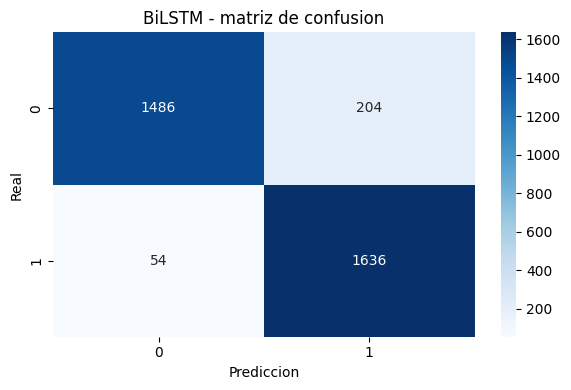

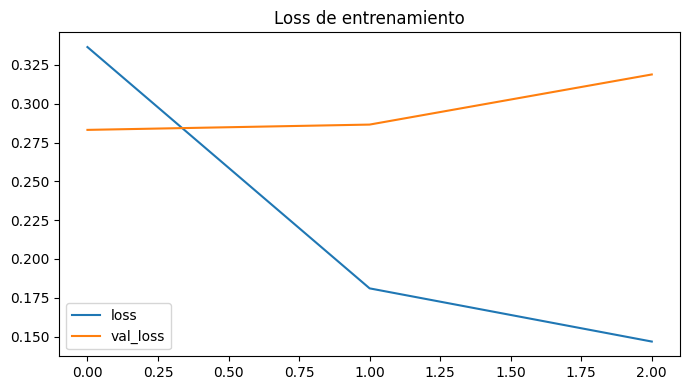

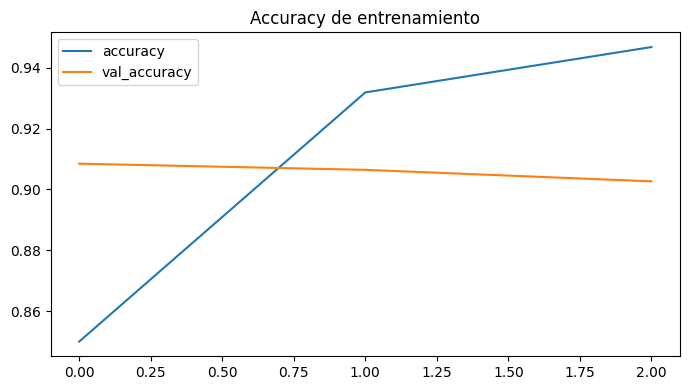

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))

sns.heatmap(confusion_matrix(y_test, predictions["test"]), annot=True, fmt="d", cmap="Blues", ax=ax)
ax.set_title("BiLSTM - matriz de confusion")
ax.set_xlabel("Prediccion")
ax.set_ylabel("Real")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "bilstm_confusion_matrix.png", dpi=180)
plt.show()

history_df[["loss", "val_loss"]].plot(figsize=(7, 4), title="Loss de entrenamiento")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "bilstm_training_loss.png", dpi=180)
plt.show()

history_df[["accuracy", "val_accuracy"]].plot(figsize=(7, 4), title="Accuracy de entrenamiento")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "bilstm_training_accuracy.png", dpi=180)
plt.show()

In [13]:
def short_code(text, max_chars=350):
    text = re.sub(r"\s+", " ", str(text)).strip()
    return text[:max_chars] + ("..." if len(text) > max_chars else "")


examples = test_df[["assignment", "model", "level", "label", "code_a", "code_b"]].copy()
examples["score"] = test_scores
examples["prediction"] = predictions["test"]
examples["correct"] = examples["label"] == examples["prediction"]
examples["code_a_preview"] = examples["code_a"].map(short_code)
examples["code_b_preview"] = examples["code_b"].map(short_code)

cols = ["assignment", "model", "level", "label", "prediction", "score", "correct", "code_a_preview", "code_b_preview"]
display(examples.sort_values(["correct", "score"], ascending=[True, False])[cols].head(10))

,assignment,model,level,label,prediction,score,correct,code_a_preview,code_b_preview
2210,assignment380,deep-seek-coder,negative,0,1,0.999952,False,"def get_Pairs_Count(arr,n,sum): count = 0 for ...","def get_pairs_count(arr, n, sum): count = 0 fo..."
1765,assignment152,deep-seek-coder,negative,0,1,0.999933,False,"def no_of_subsequences(arr, k): n = len(arr) d...","def get_total_number_of_sequences(m,n): T=[[0 ..."
1866,assignment187,gpt-4o-mini,negative,0,1,0.999920,False,"def unique_Element(arr,n): s = set(arr) if (le...","def check_last (arr,n,p): _sum = 0 for i in ra..."
3158,assignment840,gpt-4o-mini,negative,0,1,0.999805,False,"def check_equilateral(x,y,z): if x == y == z: ...","def max_sub_array_sum_repeated(a, n, k): max_s..."
3270,assignment901,gpt-4o-mini,negative,0,1,0.999714,False,import re def text_match(text): patterns = '^[...,import re regex = r'^[a-z]$|^([a-z]).*\1$' def...
2050,assignment314,gpt-4o-mini,negative,0,1,0.999667,False,"def min_Jumps(a, b, d): temp = a a = min(a, b)...","def ap_sum(a,n,d): total = (n * (2 * a + (n - ..."
1935,assignment239,gpt-4o-mini,negative,0,1,0.999647,False,"def div_of_nums(nums,m,n): result = list(filte...","def min_Jumps(a, b, d): temp = a a = min(a, b)..."
2851,assignment674,deep-seek-coder,negative,0,1,0.999639,False,"def No_of_Triangle(N,K): if (N < K): return -1...","def min_Swaps(s1,s2) : c0 = 0; c1 = 0; for i i..."
2562,assignment507,gpt-4o-mini,negative,0,1,0.999595,False,import math def sumofFactors(n) : if (n % 2 !=...,import math def find_Digits(n): if (n < 0): re...
2503,assignment492,gpt-4o-mini,negative,0,1,0.999478,False,"def count_no (A,N,L,R): count = 0 for i in ran...","def get_pairs_count(arr, n, sum): count = 0 fo..."


In [14]:
display(examples.sort_values(["correct", "score"], ascending=[True, False])[cols].tail(10))

,assignment,model,level,label,prediction,score,correct,code_a_preview,code_b_preview
2579,assignment51,gpt-4o-mini,negative,0,0,0.000013,True,"def lcs_of_three(X, Y, Z, m, n, o): L = [[[0 f...",def min_length_list(input_list): min_length = ...
2577,assignment51,gpt-4o-mini,negative,0,0,0.000011,True,"def lcs_of_three(X, Y, Z, m, n, o): L = [[[0 f...",import math def divSum(n): sum = 1; i = 2; whi...
1926,assignment226,gpt-4o-mini,negative,0,0,0.000011,True,def sum_series(n): if n < 1: return 0 else: re...,"def lcs_of_three(X, Y, Z, m, n, o): L = [[[0 f..."
3071,assignment797,gpt-4o-mini,negative,0,0,0.000009,True,"def coin_change(S, m, n): table = [[0 for x in...",def find_Parity(x): y = x ^ (x >> 1); y = y ^ ...
1886,assignment199,deep-seek-coder,negative,0,0,0.000007,True,def difference(n) : S = (n*(n + 1))//2; res = ...,"def lcs_of_three(X, Y, Z, m, n, o): L = [[[0 f..."
2569,assignment51,deep-seek-coder,negative,0,0,0.000004,True,"def lcs_of_three(X, Y, Z, m, n, o): L = [[[0 f...",def sum_Of_Series(n): sum = 0 for i in range(1...
3249,assignment90,deep-seek-coder,negative,0,0,0.000003,True,def sum_Square(n) : i = 1 while i*i <= n : j =...,"def lcs_of_three(X, Y, Z, m, n, o): L = [[[0 f..."
2572,assignment51,deep-seek-coder,negative,0,0,0.000003,True,"def lcs_of_three(X, Y, Z, m, n, o): L = [[[0 f...",def first_even(nums): first_even = next((el fo...
2079,assignment334,deep-seek-coder,negative,0,0,0.000003,True,def chinese_zodiac(year): if (year - 2000) % 1...,"def lcs_of_three(X, Y, Z, m, n, o): L = [[[0 f..."
2576,assignment51,gpt-4o-mini,negative,0,0,0.000001,True,"def lcs_of_three(X, Y, Z, m, n, o): L = [[[0 f...",def is_odd(n) : if (n^1 == n-1) : return True;...


## 8. Guardado final

Se guarda el modelo final, el vocabulario, el threshold, las metricas y las predicciones de ejemplo. El mejor modelo durante entrenamiento ya quedo guardado como `best_model.keras`.

In [11]:
model_dir = MODELS_DIR / "bilstm_keras"
model_dir.mkdir(exist_ok=True)
model.save(model_dir / "model.keras")
joblib.dump(vectorizer.get_vocabulary(), model_dir / "vocabulary.joblib")
metrics_df.to_csv(METRICS_DIR / "bilstm_metrics.csv", index=False)
(model_dir / "threshold.json").write_text(json.dumps({"threshold": BILSTM_THRESHOLD}, indent=2), encoding="utf-8")
examples.drop(columns=["code_a", "code_b"]).to_csv(METRICS_DIR / "bilstm_test_predictions.csv", index=False)

print("Saved BiLSTM model in:", model_dir)


Saved BiLSTM model in: /kaggle/working/code-plagiarism-benchmark/models/bilstm_keras
